# PSYLIQ Investigative Data Analysis Internship

## Project 1: Scam Execution & Victim Profiling

### U.S. Cybercrime Victim Demographics, Scam Tactics & Government Response

**Analyst:** Divya Vasamsetti  
**Organization:** PSYLIQ  
**Tools:** Python, Pandas, Matplotlib, SQLite, Excel

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import sqlite3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
import os

print(os.getcwd())

C:\Users\91910


In [4]:
import pandas as pd

file_path = r"D:\PSYLIQ_Project_1\Data_Matrix_P1.xlsx"

age_df = pd.read_excel(file_path, sheet_name="Age_Data")
state_df = pd.read_excel(file_path, sheet_name="State_Data")

print("Age data:")
display(age_df.head())

print("State data:")
display(state_df.head())

Age data:


,Year,Age_Group,Complaints,Source_ID,Source_Page,Notes
0,2024,Under 20,17993,FBI005,8,IC3 Complaints by Age Group
1,2024,20-29,71399,FBI005,8,IC3 Complaints by Age Group
2,2024,30-39,108899,FBI005,8,IC3 Complaints by Age Group
3,2024,40-49,112755,FBI005,8,IC3 Complaints by Age Group
4,2024,50-59,84540,FBI005,8,IC3 Complaints by Age Group


State data:


,Year,State,Complaints,Source_ID,Source_Page,Notes
0,2024,California,96265,FBI005,20,Overall complaints
1,2024,Texas,62347,FBI005,20,Overall complaints
2,2024,Florida,52191,FBI005,20,Overall complaints
3,2024,New York,36468,FBI005,20,Overall complaints
4,2024,Pennsylvania,27838,FBI005,20,Overall complaints


In [5]:
print("AGE DATA YEARS:")
print(sorted(age_df["Year"].unique()))

print("\nSTATE DATA YEARS:")
print(sorted(state_df["Year"].unique()))

AGE DATA YEARS:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

STATE DATA YEARS:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [6]:
print("Age data rows:", len(age_df))
print("State data rows:", len(state_df))

Age data rows: 30
State data rows: 50


In [7]:
print("Missing values in Age Data:")
print(age_df.isnull().sum())

print("\nMissing values in State Data:")
print(state_df.isnull().sum())

Missing values in Age Data:
Year           0
Age_Group      0
Complaints     0
Source_ID      0
Source_Page    0
Notes          0
dtype: int64

Missing values in State Data:
Year           0
State          0
Complaints     0
Source_ID      0
Source_Page    0
Notes          0
dtype: int64


In [8]:
age_df.sort_values(["Year", "Age_Group"])

,Year,Age_Group,Complaints,Source_ID,Source_Page,Notes
25,2020,20-29,70791,FBI001,16,Victims by Age Group
26,2020,30-39,88364,FBI001,16,Victims by Age Group
27,2020,40-49,91568,FBI001,16,Victims by Age Group
28,2020,50-59,85967,FBI001,16,Victims by Age Group
29,2020,60+,105301,FBI001,16,Victims by Age Group
24,2020,Under 20,23186,FBI001,16,Victims by Age Group
19,2021,20-29,69390,FBI002,19,Overall IC3 complaints by age group
20,2021,30-39,88448,FBI002,19,Overall IC3 complaints by age group
21,2021,40-49,89184,FBI002,19,Overall IC3 complaints by age group
22,2021,50-59,74460,FBI002,19,Overall IC3 complaints by age group


In [9]:
state_df.sort_values(["Year", "Complaints"], ascending=[True, False])

,Year,State,Complaints,Source_ID,Source_Page,Notes
40,2020,California,69541,FBI001,23,Overall victims by state
41,2020,Florida,53793,FBI001,23,Overall victims by state
42,2020,Texas,38640,FBI001,23,Overall victims by state
43,2020,New York,34505,FBI001,23,Overall victims by state
44,2020,Illinois,20185,FBI001,23,Overall victims by state
45,2020,Pennsylvania,18636,FBI001,23,Overall victims by state
46,2020,Washington,17229,FBI001,23,Overall victims by state
47,2020,Nevada,16110,FBI001,23,Overall victims by state
48,2020,New Jersey,14829,FBI001,23,Overall victims by state
49,2020,Maryland,14804,FBI001,23,Overall victims by state


In [10]:
selected_age = age_df[
    age_df["Age_Group"].isin(["20-29", "60+"])
].copy()

selected_age = selected_age.sort_values("Year")

display(selected_age)

,Year,Age_Group,Complaints,Source_ID,Source_Page,Notes
25,2020,20-29,70791,FBI001,16,Victims by Age Group
29,2020,60+,105301,FBI001,16,Victims by Age Group
19,2021,20-29,69390,FBI002,19,Overall IC3 complaints by age group
23,2021,60+,92371,FBI002,19,Overall IC3 complaints by age group
13,2022,20-29,57978,FBI003,18,Overall IC3 complaints by age group
17,2022,60+,88262,FBI003,18,Overall IC3 complaints by age group
7,2023,20-29,62410,FBI004,17,Overall IC3 complaints by age group
11,2023,60+,101068,FBI004,17,Overall IC3 complaints by age group
1,2024,20-29,71399,FBI005,8,IC3 Complaints by Age Group
5,2024,60+,147127,FBI005,8,IC3 Complaints by Age Group


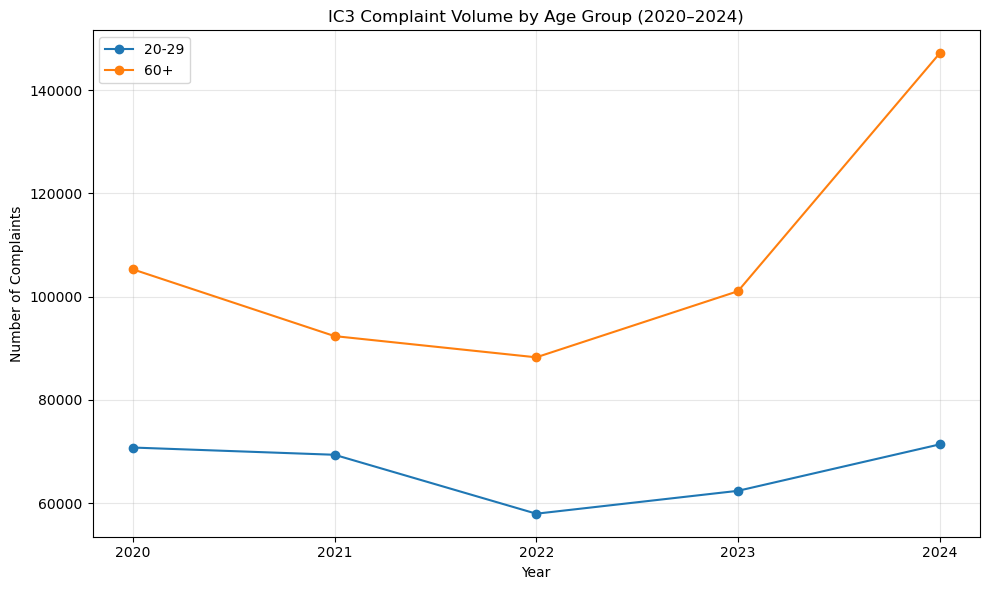

In [11]:
plt.figure(figsize=(10, 6))

for age_group in ["20-29", "60+"]:
    data = selected_age[selected_age["Age_Group"] == age_group]
    plt.plot(
        data["Year"],
        data["Complaints"],
        marker="o",
        label=age_group
    )

plt.title("IC3 Complaint Volume by Age Group (2020–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"D:\PSYLIQ_Project_1\Visualizations\age_group_trend_2020_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
state_2024 = state_df[state_df["Year"] == 2024].copy()

state_2024 = state_2024.sort_values(
    "Complaints",
    ascending=False
).head(10)

display(state_2024)

,Year,State,Complaints,Source_ID,Source_Page,Notes
0,2024,California,96265,FBI005,20,Overall complaints
1,2024,Texas,62347,FBI005,20,Overall complaints
2,2024,Florida,52191,FBI005,20,Overall complaints
3,2024,New York,36468,FBI005,20,Overall complaints
4,2024,Pennsylvania,27838,FBI005,20,Overall complaints
5,2024,Illinois,25446,FBI005,20,Overall complaints
6,2024,Ohio,24915,FBI005,20,Overall complaints
7,2024,Indiana,23659,FBI005,20,Overall complaints
8,2024,North Carolina,22021,FBI005,20,Overall complaints
9,2024,Arizona,20101,FBI005,20,Overall complaints


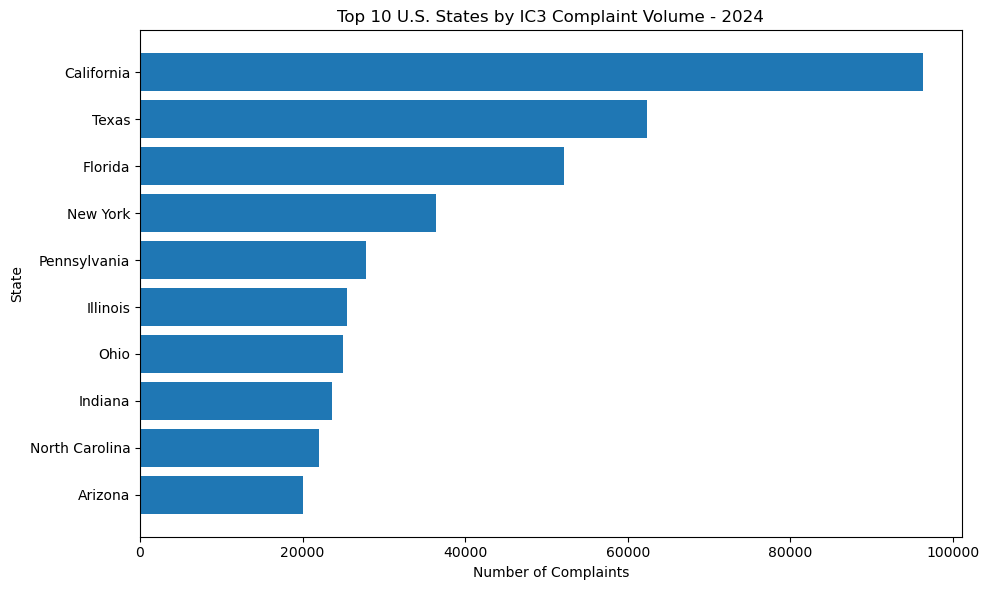

In [13]:
plt.figure(figsize=(10, 6))

plt.barh(
    state_2024["State"][::-1],
    state_2024["Complaints"][::-1]
)

plt.title("Top 10 U.S. States by IC3 Complaint Volume - 2024")
plt.xlabel("Number of Complaints")
plt.ylabel("State")
plt.tight_layout()

plt.savefig(
    r"D:\PSYLIQ_Project_1\Visualizations\top10_states_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
top_state = state_2024.iloc[0]

print("Most targeted state in 2024:")
print("State:", top_state["State"])
print("Complaints:", top_state["Complaints"])

Most targeted state in 2024:
State: California
Complaints: 96265


In [15]:
state_compare = state_df[
    state_df["Year"].isin([2020, 2024])
].pivot(
    index="State",
    columns="Year",
    values="Complaints"
)

state_compare = state_compare.dropna()

state_compare["Change"] = (
    state_compare[2024] - state_compare[2020]
)

state_compare["Growth_%"] = (
    (state_compare[2024] - state_compare[2020])
    / state_compare[2020]
) * 100

state_compare = state_compare.sort_values(
    "Growth_%",
    ascending=False
)

display(state_compare)

Year,2020,2024,Change,Growth_%
State,,,,
Texas,38640.0,62347.0,23707.0,61.353520
Pennsylvania,18636.0,27838.0,9202.0,49.377549
California,69541.0,96265.0,26724.0,38.429128
Illinois,20185.0,25446.0,5261.0,26.063909
New York,34505.0,36468.0,1963.0,5.689031
Florida,53793.0,52191.0,-1602.0,-2.978083


In [16]:
fastest_state = state_compare.iloc[0]

print("Fastest-growing state in our 2020-2024 comparison:")
print("State:", fastest_state.name)
print("2020 complaints:", fastest_state[2020])
print("2024 complaints:", fastest_state[2024])
print("Growth:", round(fastest_state["Growth_%"], 2), "%")

Fastest-growing state in our 2020-2024 comparison:
State: Texas
2020 complaints: 38640.0
2024 complaints: 62347.0
Growth: 61.35 %


In [17]:
age_compare = age_df[
    age_df["Year"].isin([2020, 2024])
].pivot(
    index="Age_Group",
    columns="Year",
    values="Complaints"
)

age_compare["Change"] = (
    age_compare[2024] - age_compare[2020]
)

age_compare["Growth_%"] = (
    (age_compare[2024] - age_compare[2020])
    / age_compare[2020]
) * 100

age_compare = age_compare.sort_values(
    "Growth_%",
    ascending=False
)

display(age_compare)

Year,2020,2024,Change,Growth_%
Age_Group,,,,
60+,105301,147127,41826,39.720421
30-39,88364,108899,20535,23.239102
40-49,91568,112755,21187,23.137996
20-29,70791,71399,608,0.858866
50-59,85967,84540,-1427,-1.659939
Under 20,23186,17993,-5193,-22.397136


In [18]:
fastest_age = age_compare.iloc[0]

print("Fastest-growing age group:")
print("Age Group:", fastest_age.name)
print("2020:", fastest_age[2020])
print("2024:", fastest_age[2024])
print("Growth:", round(fastest_age["Growth_%"], 2), "%")

Fastest-growing age group:
Age Group: 60+
2020: 105301.0
2024: 147127.0
Growth: 39.72 %


In [19]:
print(
    f"From 2020 to 2024, the {fastest_age.name} age group "
    f"showed the highest percentage growth in our dataset, "
    f"increasing from {int(fastest_age[2020]):,} complaints in 2020 "
    f"to {int(fastest_age[2024]):,} complaints in 2024, "
    f"a growth of approximately {fastest_age['Growth_%']:.1f}%."
)

From 2020 to 2024, the 60+ age group showed the highest percentage growth in our dataset, increasing from 105,301 complaints in 2020 to 147,127 complaints in 2024, a growth of approximately 39.7%.


# Executive Summary

This project investigates three dimensions of U.S. scam activity:

1. Victim demographics and geographic concentration.
2. Scammer tactics, urgency language, platforms and payment demands.
3. Government anti-scam enforcement and future technology opportunities.

Publicly available FBI, FTC, CISA and U.S. Department of Justice sources were structured into analytical datasets. Python was used for data cleaning, exploratory analysis, visualization and SQLite-based relational analysis.

The analysis identifies demographic and geographic patterns, recurring scam narrative characteristics, common payment mechanisms, government recovery actions and opportunities for real-time technology-based intervention.

# 1.1 Victim Demographics & Geographical Hotspots

## Objective
To analyze the distribution of IC3 complaints across age groups and U.S. states from 2020 to 2024.

## Age Group Trend
The analysis compares complaint volumes for the 20–29 and 60+ age groups between 2020 and 2024.

## Geographic Hotspots
The 2024 analysis identifies the Top 10 states by raw complaint volume.

## Key Observation

The 60+ age group showed the highest percentage growth in our analyzed age-group dataset, increasing from 105,301 complaints in 2020 to 147,127 in 2024, a growth of approximately 39.7%. At the geographic level, Texas showed the fastest growth among the analyzed states, increasing from 38,640 complaints in 2020 to 62,347 in 2024, a growth of approximately 61.4%.

In [20]:
state_2024 = state_df[state_df["Year"] == 2024].copy()

state_2024 = state_2024.sort_values(
    "Complaints",
    ascending=False
).head(10)

display(state_2024)

,Year,State,Complaints,Source_ID,Source_Page,Notes
0,2024,California,96265,FBI005,20,Overall complaints
1,2024,Texas,62347,FBI005,20,Overall complaints
2,2024,Florida,52191,FBI005,20,Overall complaints
3,2024,New York,36468,FBI005,20,Overall complaints
4,2024,Pennsylvania,27838,FBI005,20,Overall complaints
5,2024,Illinois,25446,FBI005,20,Overall complaints
6,2024,Ohio,24915,FBI005,20,Overall complaints
7,2024,Indiana,23659,FBI005,20,Overall complaints
8,2024,North Carolina,22021,FBI005,20,Overall complaints
9,2024,Arizona,20101,FBI005,20,Overall complaints


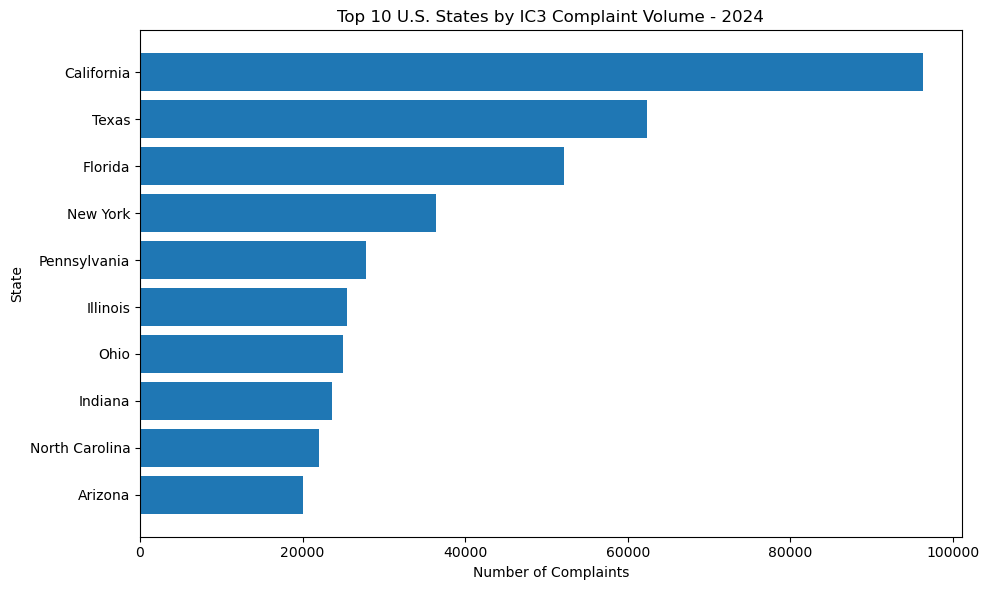

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    state_2024["State"][::-1],
    state_2024["Complaints"][::-1]
)

plt.title("Top 10 U.S. States by IC3 Complaint Volume - 2024")
plt.xlabel("Number of Complaints")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    r"D:\PSYLIQ_Project_1\Visualizations\top10_states_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
top_state = state_2024.iloc[0]

print("Most targeted state in 2024:")
print("State:", top_state["State"])
print("Complaints:", f'{top_state["Complaints"]:,}')

Most targeted state in 2024:
State: California
Complaints: 96,265


In [23]:
state_compare = state_df[
    state_df["Year"].isin([2020, 2024])
].pivot(
    index="State",
    columns="Year",
    values="Complaints"
)

state_compare = state_compare.dropna()

state_compare["Change"] = (
    state_compare[2024] - state_compare[2020]
)

state_compare["Growth_%"] = (
    (state_compare[2024] - state_compare[2020])
    / state_compare[2020]
) * 100

state_compare = state_compare.sort_values(
    "Growth_%",
    ascending=False
)

display(state_compare)

Year,2020,2024,Change,Growth_%
State,,,,
Texas,38640.0,62347.0,23707.0,61.353520
Pennsylvania,18636.0,27838.0,9202.0,49.377549
California,69541.0,96265.0,26724.0,38.429128
Illinois,20185.0,25446.0,5261.0,26.063909
New York,34505.0,36468.0,1963.0,5.689031
Florida,53793.0,52191.0,-1602.0,-2.978083


In [24]:
fastest_state = state_compare.iloc[0]

print("Fastest-growing state:")
print("State:", fastest_state.name)
print("2020:", f'{fastest_state[2020]:,.0f}')
print("2024:", f'{fastest_state[2024]:,.0f}')
print("Growth:", f'{fastest_state["Growth_%"]:.2f}%')

Fastest-growing state:
State: Texas
2020: 38,640
2024: 62,347
Growth: 61.35%


In [25]:
age_compare = age_df[
    age_df["Year"].isin([2020, 2024])
].pivot(
    index="Age_Group",
    columns="Year",
    values="Complaints"
)

age_compare["Change"] = (
    age_compare[2024] - age_compare[2020]
)

age_compare["Growth_%"] = (
    (age_compare[2024] - age_compare[2020])
    / age_compare[2020]
) * 100

age_compare = age_compare.sort_values(
    "Growth_%",
    ascending=False
)

display(age_compare)

Year,2020,2024,Change,Growth_%
Age_Group,,,,
60+,105301,147127,41826,39.720421
30-39,88364,108899,20535,23.239102
40-49,91568,112755,21187,23.137996
20-29,70791,71399,608,0.858866
50-59,85967,84540,-1427,-1.659939
Under 20,23186,17993,-5193,-22.397136


In [26]:
fastest_age = age_compare.iloc[0]

print("Fastest-growing age group:")
print("Age Group:", fastest_age.name)
print("2020:", f'{fastest_age[2020]:,.0f}')
print("2024:", f'{fastest_age[2024]:,.0f}')
print("Growth:", f'{fastest_age["Growth_%"]:.2f}%')

Fastest-growing age group:
Age Group: 60+
2020: 105,301
2024: 147,127
Growth: 39.72%


In [27]:
print(
    f"From 2020 to 2024, the {fastest_age.name} age group "
    f"showed the highest percentage growth in our dataset, "
    f"increasing from {fastest_age[2020]:,.0f} complaints in 2020 "
    f"to {fastest_age[2024]:,.0f} complaints in 2024, "
    f"representing approximately {fastest_age['Growth_%']:.1f}% growth."
)

From 2020 to 2024, the 60+ age group showed the highest percentage growth in our dataset, increasing from 105,301 complaints in 2020 to 147,127 complaints in 2024, representing approximately 39.7% growth.


In [28]:
age_compare.reset_index()

Year,Age_Group,2020,2024,Change,Growth_%
0,60+,105301,147127,41826,39.720421
1,30-39,88364,108899,20535,23.239102
2,40-49,91568,112755,21187,23.137996
3,20-29,70791,71399,608,0.858866
4,50-59,85967,84540,-1427,-1.659939
5,Under 20,23186,17993,-5193,-22.397136


In [29]:
age_compare.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\age_growth_analysis.csv"
)

state_compare.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\state_growth_analysis.csv"
)

print("Analysis tables saved successfully!")

Analysis tables saved successfully!


In [30]:
file_path = r"D:\PSYLIQ_Project_1\Data_Matrix_P1.xlsx"

print("File path set successfully:")
print(file_path)

File path set successfully:
D:\PSYLIQ_Project_1\Data_Matrix_P1.xlsx


In [31]:
tactics_df = pd.read_excel(
    file_path,
    sheet_name="Tactics_Data"
)

print("Tactics data loaded successfully!")
print("Rows:", len(tactics_df))
print("Columns:", list(tactics_df.columns))

display(tactics_df)

Tactics data loaded successfully!
Rows: 12
Columns: ['Source_ID', 'Scam_Type', 'Platform', 'Phrase_or_Threat', 'Payment_Method', 'Demand', 'Urgency_Level', 'Source_Year']


,Source_ID,Scam_Type,Platform,Phrase_or_Threat,Payment_Method,Demand,Urgency_Level,Source_Year
0,TACT001,Tech Support,Phone,Your account has been hacked,Cryptocurrency,Act immediately,High,2022
1,TACT002,Tech Support,Pop-up,You have a virus,Gift Card,Pay for support,High,2022
2,TACT003,Government Impersonation,Phone,You will be arrested if you do not pay,Cryptocurrency,Pay immediately,High,2022
3,TACT004,Imposter Scam,Phone,Your benefits will be suspended,Gift Card,Make payment now,High,2020
4,TACT005,Imposter Scam,Text,You need to verify your information,Wire Transfer,Verify information,Medium,2020
5,TACT006,Tech Support,Phone,Your money is going to be gone,Wire Transfer,Move money immediately,High,2022
6,TACT007,Government Impersonation,Phone,You are in trouble with the law,Cryptocurrency,Pay a fine,High,2022
7,TACT008,Phishing,Email,URGENT - Your Recent Order,NaN,Click or verify,High,2023
8,TACT009,Tech Support,Phone,You must act now,Gift Card,Make immediate payment,High,2022
9,TACT010,Investment Scam,Online,Guaranteed returns,Cryptocurrency,Send investment funds,Medium,2023


In [32]:
print("Missing values:")
print(tactics_df.isnull().sum())

print("\nDuplicate rows:")
print(tactics_df.duplicated().sum())

Missing values:
Source_ID           0
Scam_Type           0
Platform            0
Phrase_or_Threat    0
Payment_Method      1
Demand              0
Urgency_Level       0
Source_Year         0
dtype: int64

Duplicate rows:
0


In [33]:
scam_type_counts = tactics_df["Scam_Type"].value_counts()

print("Scam Type Distribution:")
display(scam_type_counts)

Scam Type Distribution:


Scam_Type
Tech Support                5
Government Impersonation    3
Imposter Scam               2
Phishing                    1
Investment Scam             1
Name: count, dtype: int64

In [34]:
platform_counts = tactics_df["Platform"].value_counts()

print("Platform Distribution:")
display(platform_counts)

Platform Distribution:


Platform
Phone     7
Pop-up    2
Text      1
Email     1
Online    1
Name: count, dtype: int64

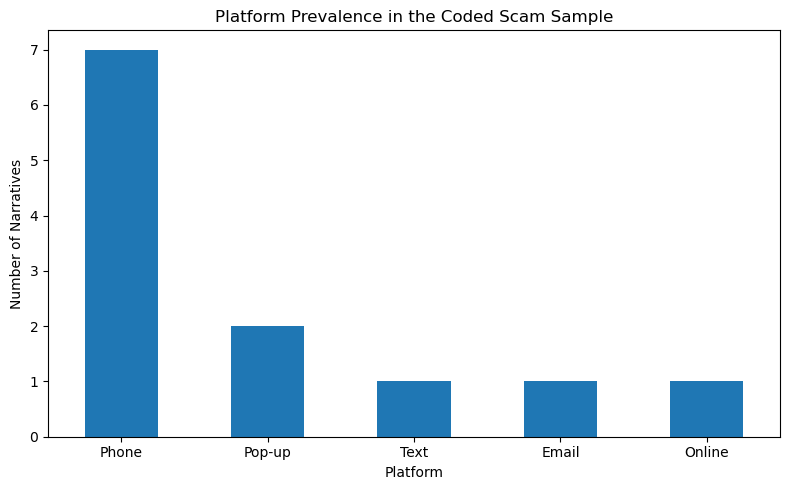

In [35]:
plt.figure(figsize=(8, 5))

platform_counts.plot(kind="bar")

plt.title("Platform Prevalence in the Coded Scam Sample")
plt.xlabel("Platform")
plt.ylabel("Number of Narratives")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    r"D:\PSYLIQ_Project_1\Visualizations\platform_prevalence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
import re
from collections import Counter

urgency_text = " ".join(
    tactics_df["Phrase_or_Threat"]
    .dropna()
    .astype(str)
    .str.lower()
)

urgency_keywords = [
    "urgent",
    "immediately",
    "now",
    "hacked",
    "arrested",
    "suspended",
    "virus",
    "gone",
    "protect",
    "must"
]

keyword_counts = Counter()

for word in urgency_keywords:
    keyword_counts[word] = len(
        re.findall(r"\b" + re.escape(word) + r"\b", urgency_text)
    )

top5_keywords = pd.DataFrame(
    keyword_counts.most_common(5),
    columns=["Keyword", "Frequency"]
)

display(top5_keywords)

,Keyword,Frequency
0,urgent,1
1,immediately,1
2,now,1
3,hacked,1
4,arrested,1


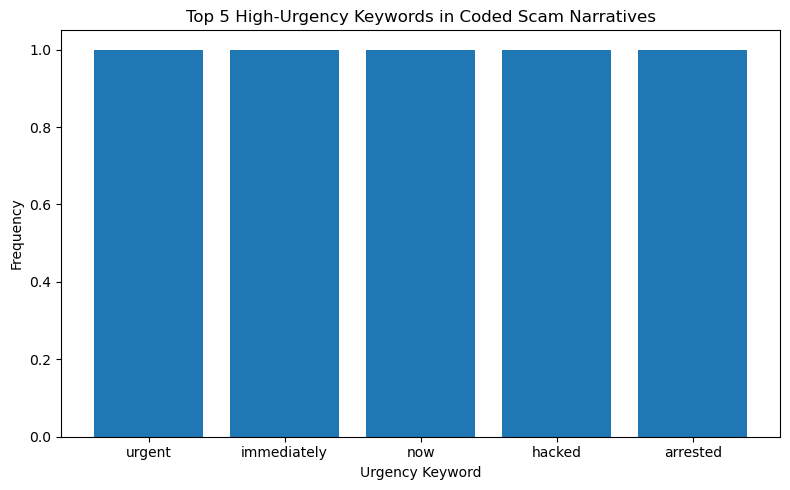

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    top5_keywords["Keyword"],
    top5_keywords["Frequency"]
)

plt.title("Top 5 High-Urgency Keywords in Coded Scam Narratives")
plt.xlabel("Urgency Keyword")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    r"D:\PSYLIQ_Project_1\Visualizations\top5_urgency_keywords.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
payment_counts = (
    tactics_df[
        tactics_df["Payment_Method"].notna()
        & (tactics_df["Payment_Method"] != "None")
    ]["Payment_Method"]
    .value_counts()
    .head(3)
)

print("Top 3 Payment Methods:")
display(payment_counts)

Top 3 Payment Methods:


Payment_Method
Cryptocurrency    4
Gift Card         4
Wire Transfer     3
Name: count, dtype: int64

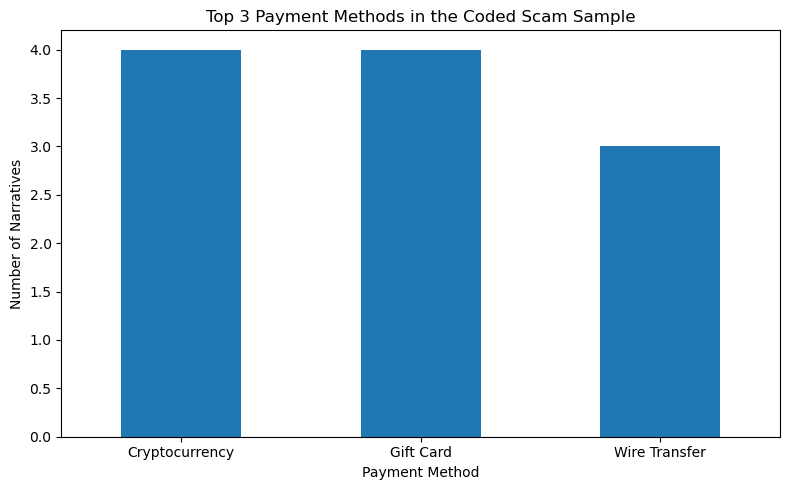

In [39]:
plt.figure(figsize=(8, 5))

payment_counts.plot(kind="bar")

plt.title("Top 3 Payment Methods in the Coded Scam Sample")
plt.xlabel("Payment Method")
plt.ylabel("Number of Narratives")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    r"D:\PSYLIQ_Project_1\Visualizations\top3_payment_methods.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
top5_keywords.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\top5_urgency_keywords.csv",
    index=False
)

payment_counts.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\top3_payment_methods.csv"
)

platform_counts.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\platform_counts.csv"
)

print("All 1.2 analysis results saved successfully!")

All 1.2 analysis results saved successfully!


In [41]:
script_steps = pd.DataFrame({
    "Step": [1, 2, 3, 4, 5, 6],
    "Scammer_Action": [
        "Initial contact",
        "Create fear or urgency",
        "Claim authority or technical problem",
        "Give specific instructions",
        "Demand payment or sensitive information",
        "Pressure victim to complete payment immediately"
    ],
    "Victim_Response_Target": [
        "Answer the call/message",
        "Become worried",
        "Trust the scammer's explanation",
        "Follow instructions",
        "Send money or information",
        "Complete the transaction before verifying"
    ]
})

display(script_steps)

,Step,Scammer_Action,Victim_Response_Target
0,1,Initial contact,Answer the call/message
1,2,Create fear or urgency,Become worried
2,3,Claim authority or technical problem,Trust the scammer's explanation
3,4,Give specific instructions,Follow instructions
4,5,Demand payment or sensitive information,Send money or information
5,6,Pressure victim to complete payment immediately,Complete the transaction before verifying


In [42]:
intervention_df = pd.DataFrame({
    "Stage": [
        "Initial Contact",
        "Urgency Creation",
        "Authority Claim",
        "Payment Demand",
        "Transaction"
    ],
    "Intervention": [
        "Flag unexpected calls, texts, emails and pop-ups",
        "Warn when urgent/threatening language is detected",
        "Require independent verification of claimed identity",
        "Block or warn about high-risk payment requests",
        "Provide a final confirmation and reporting step"
    ]
})

display(intervention_df)

,Stage,Intervention
0,Initial Contact,"Flag unexpected calls, texts, emails and pop-ups"
1,Urgency Creation,Warn when urgent/threatening language is detected
2,Authority Claim,Require independent verification of claimed id...
3,Payment Demand,Block or warn about high-risk payment requests
4,Transaction,Provide a final confirmation and reporting step


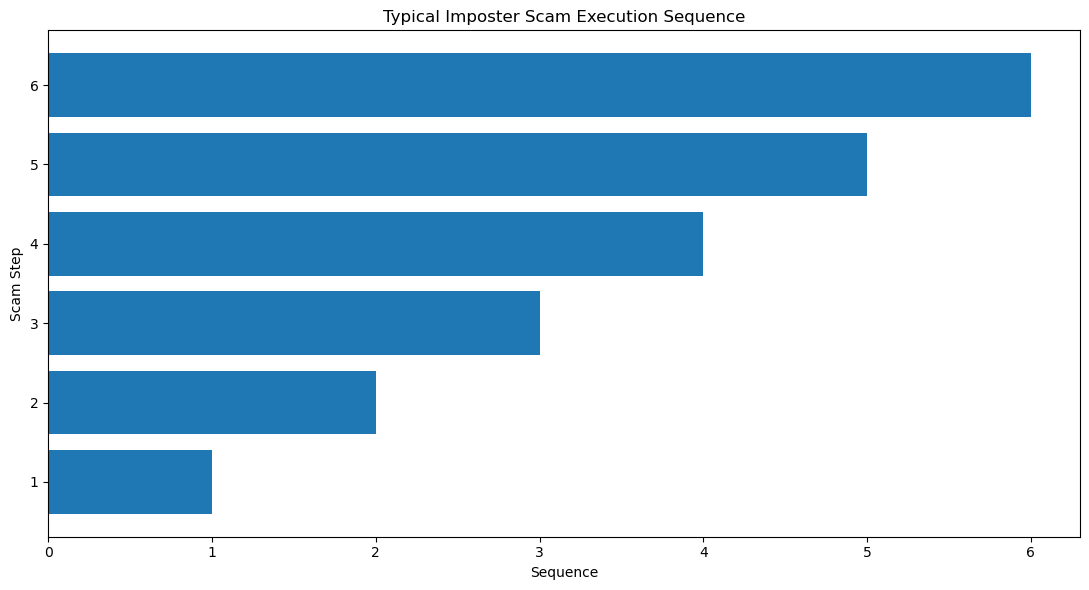

In [43]:
plt.figure(figsize=(11, 6))

plt.barh(
    script_steps["Step"].astype(str),
    script_steps["Step"]
)

plt.title("Typical Imposter Scam Execution Sequence")
plt.xlabel("Sequence")
plt.ylabel("Scam Step")

plt.tight_layout()

plt.savefig(
    r"D:\PSYLIQ_Project_1\Visualizations\scammer_script_sequence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
platform_percentage = (
    platform_counts / platform_counts.sum() * 100
).round(1)

platform_percentage_df = platform_percentage.reset_index()

platform_percentage_df.columns = [
    "Platform",
    "Percentage"
]

display(platform_percentage_df)

,Platform,Percentage
0,Phone,58.3
1,Pop-up,16.7
2,Text,8.3
3,Email,8.3
4,Online,8.3


In [45]:
payment_percentage = (
    payment_counts / payment_counts.sum() * 100
).round(1)

payment_percentage_df = payment_percentage.reset_index()

payment_percentage_df.columns = [
    "Payment_Method",
    "Percentage"
]

display(payment_percentage_df)

,Payment_Method,Percentage
0,Cryptocurrency,36.4
1,Gift Card,36.4
2,Wire Transfer,27.3


In [46]:
print(
    "Observation: The coded scam narratives show that scammers "
    "frequently combine urgency, authority claims, and immediate "
    "payment demands. This combination is designed to reduce the "
    "victim's time for independent verification."
)

Observation: The coded scam narratives show that scammers frequently combine urgency, authority claims, and immediate payment demands. This combination is designed to reduce the victim's time for independent verification.


In [47]:
script_steps.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\scammer_script.csv",
    index=False
)

intervention_df.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\intervention_points.csv",
    index=False
)

platform_percentage_df.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\platform_percentage.csv",
    index=False
)

payment_percentage_df.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\payment_percentage.csv",
    index=False
)

print("1.2 supporting files saved successfully!")

1.2 supporting files saved successfully!


# 1.2 Scammer Tactics & Intervention Analysis

## Objective

This section analyzes scam narratives to identify recurring urgency language, scam platforms, payment methods, and the typical execution sequence used in imposter scams.

## Methodology

A coded sample of scam narratives was created from official FBI, FTC, and CISA guidance and consumer-advisory material. The sample was structured into scam type, platform, phrase/threat, payment method, demand, urgency level, and source year.

## High-Urgency Language

The coded sample was analyzed using Python string matching and frequency counting to identify recurring urgency-related keywords.

## Payment Methods

Payment methods were categorized and ranked using frequency analysis.

## Typical Scammer Script

1. Initial contact
2. Creation of fear or urgency
3. Authority or problem claim
4. Specific instructions
5. Payment or information demand
6. Immediate transaction pressure

## Intervention Strategy

Potential intervention points include detection of unexpected contact, urgency-language warnings, independent identity verification, payment-risk warnings, and final transaction confirmation.

## Key Observation

The coded narratives demonstrate a recurring combination of urgency, authority claims, and immediate payment pressure. These mechanisms create opportunities for real-time intervention before a victim completes the transaction.

In [48]:
gov_df = pd.read_excel(
    file_path,
    sheet_name="Gov_Actions"
)

display(gov_df)

,Action_ID,Agency,Targeted_Scam_Type,Date_of_Action,Est_Funds_Recovered_USD,Source_ID
0,GA001,DOJ/FBI,COVID-19 Relief Fraud,2021-03-26,569000000,SRCG001
1,GA002,DOJ/FBI/USPS,Money Mule Fraud,2021-12-03,0,SRCG002
2,GA003,DOJ,Cryptocurrency Fraud,2022-06-30,0,SRCG003
3,GA004,DOJ,COVID-19 Relief Fraud,2022-03-10,1000000000,SRCG004
4,GA005,DOJ/FBI/USSS,Business Email Compromise,2022-12-09,0,SRCG005
5,GA006,DOJ,COVID-19 Relief Fraud,2023-08-23,1400000000,SRCG006
6,GA007,DOJ,Fraudulent Consumer Charges,2023-12-15,0,SRCG007
7,GA008,DOJ/FBI,Tech Support Scam,2024-03-08,1400000,SRCG008
8,GA009,DOJ/FBI,Business Email Compromise,2024-04-26,2288385,SRCG009
9,GA010,DOJ/FBI,Crypto Investment Scam,2024-07-16,2546415,SRCG010


In [49]:
print("Government actions:", len(gov_df))

print("\nMissing values:")
print(gov_df.isnull().sum())

print("\nAgencies:")
print(gov_df["Agency"].value_counts())

Government actions: 10

Missing values:
Action_ID                  0
Agency                     0
Targeted_Scam_Type         0
Date_of_Action             0
Est_Funds_Recovered_USD    0
Source_ID                  0
dtype: int64

Agencies:
Agency
DOJ/FBI         4
DOJ             4
DOJ/FBI/USPS    1
DOJ/FBI/USSS    1
Name: count, dtype: int64


In [50]:
gov_df["Date_of_Action"] = pd.to_datetime(
    gov_df["Date_of_Action"]
)

gov_df["Year"] = gov_df["Date_of_Action"].dt.year

display(gov_df)

,Action_ID,Agency,Targeted_Scam_Type,Date_of_Action,Est_Funds_Recovered_USD,Source_ID,Year
0,GA001,DOJ/FBI,COVID-19 Relief Fraud,2021-03-26,569000000,SRCG001,2021
1,GA002,DOJ/FBI/USPS,Money Mule Fraud,2021-12-03,0,SRCG002,2021
2,GA003,DOJ,Cryptocurrency Fraud,2022-06-30,0,SRCG003,2022
3,GA004,DOJ,COVID-19 Relief Fraud,2022-03-10,1000000000,SRCG004,2022
4,GA005,DOJ/FBI/USSS,Business Email Compromise,2022-12-09,0,SRCG005,2022
5,GA006,DOJ,COVID-19 Relief Fraud,2023-08-23,1400000000,SRCG006,2023
6,GA007,DOJ,Fraudulent Consumer Charges,2023-12-15,0,SRCG007,2023
7,GA008,DOJ/FBI,Tech Support Scam,2024-03-08,1400000,SRCG008,2024
8,GA009,DOJ/FBI,Business Email Compromise,2024-04-26,2288385,SRCG009,2024
9,GA010,DOJ/FBI,Crypto Investment Scam,2024-07-16,2546415,SRCG010,2024


In [51]:
agency_recovery = (
    gov_df.groupby("Agency")["Est_Funds_Recovered_USD"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

display(agency_recovery)

,count,sum,mean
Agency,,,
DOJ,4,2400000000,600000000.0
DOJ/FBI,4,575234800,143808700.0
DOJ/FBI/USPS,1,0,0.0
DOJ/FBI/USSS,1,0,0.0


In [52]:
highest_agency = agency_recovery.index[0]
highest_average = agency_recovery.iloc[0]["mean"]

print("Agency with highest average estimated recovery:")
print(highest_agency)

print(
    "Average recovery per action: "
    f"${highest_average:,.2f}"
)

Agency with highest average estimated recovery:
DOJ
Average recovery per action: $600,000,000.00


In [53]:
import sqlite3

conn = sqlite3.connect(":memory:")

gov_df.to_sql(
    "government_actions",
    conn,
    index=False,
    if_exists="replace"
)

query = """
SELECT
    Agency,
    COUNT(*) AS Actions,
    SUM(Est_Funds_Recovered_USD) AS Total_Recovered,
    AVG(Est_Funds_Recovered_USD) AS Average_Recovered_Per_Action
FROM government_actions
GROUP BY Agency
ORDER BY Average_Recovered_Per_Action DESC;
"""

sql_result = pd.read_sql_query(
    query,
    conn
)

display(sql_result)

,Agency,Actions,Total_Recovered,Average_Recovered_Per_Action
0,DOJ,4,2400000000,600000000.0
1,DOJ/FBI,4,575234800,143808700.0
2,DOJ/FBI/USSS,1,0,0.0
3,DOJ/FBI/USPS,1,0,0.0


In [54]:
future_defense = pd.DataFrame({
    "Technology": [
        "NLP / AI Language Detection",
        "Behavioral Anomaly Detection",
        "Voice/Video Deepfake Detection"
    ],
    "Psyliq_Use_Case": [
        "Detect urgency, threats, impersonation language and suspicious payment requests in messages or calls.",
        "Detect unusual transaction or communication behavior and flag activity before funds are transferred.",
        "Analyze suspicious voice/video content and identify potential synthetic or cloned media."
    ],
    "Expected_Benefit": [
        "Earlier warning to potential victims",
        "Real-time fraud intervention",
        "Protection against AI-enabled impersonation"
    ]
})

display(future_defense)

,Technology,Psyliq_Use_Case,Expected_Benefit
0,NLP / AI Language Detection,"Detect urgency, threats, impersonation languag...",Earlier warning to potential victims
1,Behavioral Anomaly Detection,Detect unusual transaction or communication be...,Real-time fraud intervention
2,Voice/Video Deepfake Detection,Analyze suspicious voice/video content and ide...,Protection against AI-enabled impersonation


In [55]:
future_defense.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\future_defense_strategy.csv",
    index=False
)

print("Future defense strategy saved.")

Future defense strategy saved.


In [56]:
enforcement_gap = """
Major enforcement gap: government agencies can investigate, prosecute,
and recover funds after fraud occurs, but victims may still need
real-time intervention during the scam itself. The growing use of
AI-generated messages, voice cloning, and highly convincing social
engineering increases the need for private-sector systems that can
detect suspicious interactions before a payment is completed.
"""

print(enforcement_gap)


Major enforcement gap: government agencies can investigate, prosecute,
and recover funds after fraud occurs, but victims may still need
real-time intervention during the scam itself. The growing use of
AI-generated messages, voice cloning, and highly convincing social
engineering increases the need for private-sector systems that can
detect suspicious interactions before a payment is completed.



In [57]:
future_paragraph = """
The future of anti-scamming will increasingly depend on real-time,
technology-assisted intervention rather than relying only on
post-incident investigation. Psyliq can develop an AI-powered
language analysis layer to detect urgency, threats, impersonation
patterns and suspicious payment requests in communications. Second,
behavioral anomaly detection can identify unusual transaction or
communication patterns and trigger additional verification before
funds are transferred. Third, deepfake and voice-analysis technology
can help identify AI-generated or cloned audio and video used in
impersonation scams. These capabilities should operate with human
review, strong privacy controls and continuous model evaluation
because attackers can also adapt their techniques to evade AI
systems.
"""

print(future_paragraph)


The future of anti-scamming will increasingly depend on real-time,
technology-assisted intervention rather than relying only on
post-incident investigation. Psyliq can develop an AI-powered
language analysis layer to detect urgency, threats, impersonation
patterns and suspicious payment requests in communications. Second,
behavioral anomaly detection can identify unusual transaction or
communication patterns and trigger additional verification before
funds are transferred. Third, deepfake and voice-analysis technology
can help identify AI-generated or cloned audio and video used in
impersonation scams. These capabilities should operate with human
review, strong privacy controls and continuous model evaluation
because attackers can also adapt their techniques to evade AI
systems.



# 1.3 Government Response & Future Defense

## Objective

This section evaluates major U.S. government anti-scam enforcement actions from 2020–2024 and considers how emerging technology can strengthen future fraud prevention.

## Government Enforcement Analysis

Ten major government actions were structured into a relational-style dataset containing Action_ID, Agency, Targeted_Scam_Type, Date_of_Action, Est_Funds_Recovered_USD, and Source_ID.

A SQLite query was used to calculate the average estimated funds recovered per government action.

## Technology and Future Threats

Recent FBI guidance indicates that criminals are increasingly using artificial intelligence to improve phishing, social engineering, voice cloning and video impersonation.

NIST research indicates that machine learning can support detection of previously unseen cyber attacks, while also highlighting limitations related to accuracy, robustness and adversarial attacks.

## Three Future Technologies for Psyliq

1. **AI/NLP Scam Detection**  
   Detect urgency, threats, impersonation language and suspicious payment requests.

2. **Behavioral Anomaly Detection**  
   Identify unusual communication and transaction patterns before funds are transferred.

3. **Deepfake and Voice Analysis**  
   Detect potentially synthetic or cloned audio/video used for impersonation.

## Enforcement Gap

A major gap is the limited ability to intervene in real time while a victim is actively communicating with a scammer. Government enforcement is essential, but private-sector technology can provide an additional prevention layer before a fraudulent payment is completed.

## Future of Anti-Scamming

The future of anti-scamming will increasingly depend on combining government enforcement, intelligence sharing, artificial intelligence, behavioral analytics and real-time victim intervention.

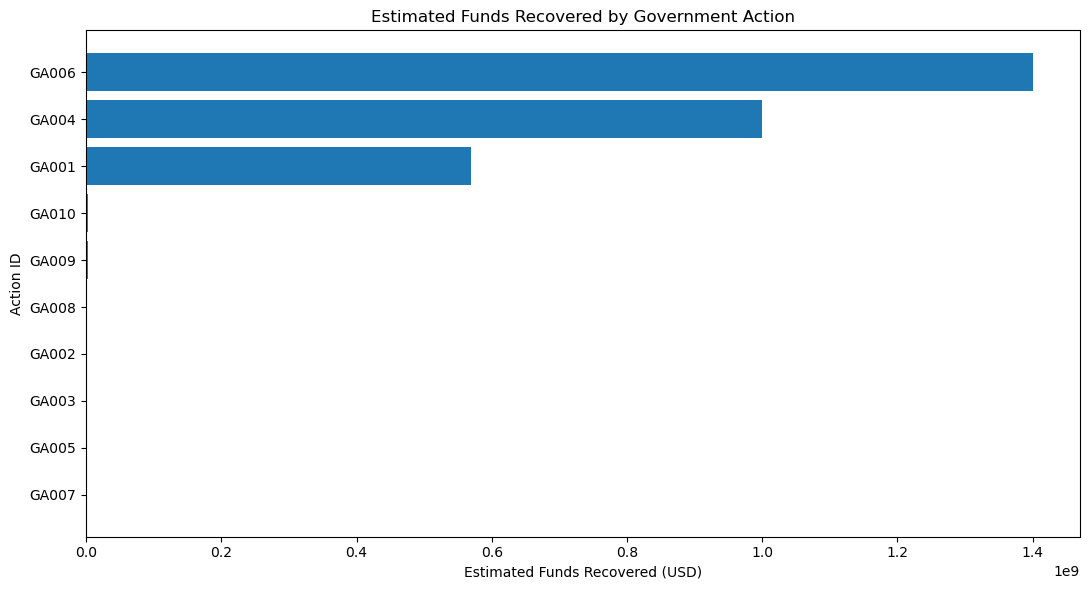

In [58]:
recovery_by_action = gov_df.sort_values(
    "Est_Funds_Recovered_USD",
    ascending=False
)

plt.figure(figsize=(11, 6))

plt.barh(
    recovery_by_action["Action_ID"][::-1],
    recovery_by_action["Est_Funds_Recovered_USD"][::-1]
)

plt.title("Estimated Funds Recovered by Government Action")
plt.xlabel("Estimated Funds Recovered (USD)")
plt.ylabel("Action ID")

plt.tight_layout()

plt.savefig(
    r"D:\PSYLIQ_Project_1\Visualizations\government_recovery_by_action.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
gov_df.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\government_actions_analysis.csv",
    index=False
)

agency_recovery.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\agency_recovery_analysis.csv"
)

sql_result.to_csv(
    r"D:\PSYLIQ_Project_1\Visualizations\agency_recovery_sql_result.csv",
    index=False
)

print("Government analysis files saved successfully!")

Government analysis files saved successfully!


In [60]:
conn.close()

print("Project 1 analysis sections 1.1, 1.2 and 1.3 completed.")
print("Remember to save the notebook with Ctrl + S.")

Project 1 analysis sections 1.1, 1.2 and 1.3 completed.
Remember to save the notebook with Ctrl + S.


# Data Limitations

- FBI IC3 complaint data represents reported complaints and should not be interpreted as the complete universe of scam incidents.
- The scam narrative analysis uses a coded sample of official FBI, FTC and CISA material rather than every scam communication in the United States.
- Government recovery figures were recorded only where an official source reported a recoverable/seized amount.
- A value of zero in the government-action dataset indicates that a comparable recovery amount was not reported in the selected source; it does not necessarily mean that no money was recovered.
- Percentage growth should be interpreted together with the underlying complaint volume.

# Conclusion

The investigation demonstrates that effective anti-scam defense requires both post-incident enforcement and proactive intervention. Victim and geographic analysis can help prioritize awareness and protection efforts, while narrative analysis reveals recurring psychological tactics such as urgency, authority claims and immediate payment pressure.

Government enforcement continues to recover funds and disrupt fraud networks, but the increasing sophistication of social engineering and AI-enabled impersonation creates a need for faster detection.

Psyliq can strengthen this prevention layer through AI-based language analysis, behavioral anomaly detection and deepfake/voice analysis, combined with human review and privacy-conscious controls.

In [61]:
import os

report_folder = r"D:\PSYLIQ_Project_1\Report"

os.makedirs(report_folder, exist_ok=True)

print("Report folder ready:")
print(report_folder)

Report folder ready:
D:\PSYLIQ_Project_1\Report


In [62]:
import os

visualization_folder = r"D:\PSYLIQ_Project_1\Visualizations"

files = os.listdir(visualization_folder)

for f in files:
    if f.endswith(".png"):
        print(f)

age_group_trend_2020_2024.png
government_recovery_by_action.png
platform_prevalence.png
scammer_script_sequence.png
top10_states_2024.png
top3_payment_methods.png
top5_urgency_keywords.png


In [63]:
print("========== KEY FINDINGS ==========")

print("\nTop 10 States - 2024")
display(state_2024)

print("\nFastest Growing State")
print(fastest_state)

print("\nFastest Growing Age Group")
print(fastest_age)

print("\nTop 5 Urgency Keywords")
display(top5_keywords)

print("\nTop 3 Payment Methods")
display(payment_counts)

print("\nAgency Recovery Analysis")
display(agency_recovery)

========== KEY FINDINGS ==========

Top 10 States - 2024


,Year,State,Complaints,Source_ID,Source_Page,Notes
0,2024,California,96265,FBI005,20,Overall complaints
1,2024,Texas,62347,FBI005,20,Overall complaints
2,2024,Florida,52191,FBI005,20,Overall complaints
3,2024,New York,36468,FBI005,20,Overall complaints
4,2024,Pennsylvania,27838,FBI005,20,Overall complaints
5,2024,Illinois,25446,FBI005,20,Overall complaints
6,2024,Ohio,24915,FBI005,20,Overall complaints
7,2024,Indiana,23659,FBI005,20,Overall complaints
8,2024,North Carolina,22021,FBI005,20,Overall complaints
9,2024,Arizona,20101,FBI005,20,Overall complaints



Fastest Growing State
Year
2020        38640.00000
2024        62347.00000
Change      23707.00000
Growth_%       61.35352
Name: Texas, dtype: float64

Fastest Growing Age Group
Year
2020        105301.000000
2024        147127.000000
Change       41826.000000
Growth_%        39.720421
Name: 60+, dtype: float64

Top 5 Urgency Keywords


,Keyword,Frequency
0,urgent,1
1,immediately,1
2,now,1
3,hacked,1
4,arrested,1



Top 3 Payment Methods


Payment_Method
Cryptocurrency    4
Gift Card         4
Wire Transfer     3
Name: count, dtype: int64


Agency Recovery Analysis


,count,sum,mean
Agency,,,
DOJ,4,2400000000,600000000.0
DOJ/FBI,4,575234800,143808700.0
DOJ/FBI/USPS,1,0,0.0
DOJ/FBI/USSS,1,0,0.0


In [64]:
print("========== SQL ANALYSIS ==========")

display(sql_result)

========== SQL ANALYSIS ==========


,Agency,Actions,Total_Recovered,Average_Recovered_Per_Action
0,DOJ,4,2400000000,600000000.0
1,DOJ/FBI,4,575234800,143808700.0
2,DOJ/FBI/USSS,1,0,0.0
3,DOJ/FBI/USPS,1,0,0.0


In [65]:
print("========== DATASET VALIDATION ==========")

print("Age records:", len(age_df))
print("State records:", len(state_df))
print("Tactic records:", len(tactics_df))
print("Government actions:", len(gov_df))

print("\nYears in Age Data:")
print(sorted(age_df["Year"].unique()))

print("\nYears in State Data:")
print(sorted(state_df["Year"].unique()))

print("\nGovernment action years:")
print(sorted(gov_df["Year"].unique()))

========== DATASET VALIDATION ==========
Age records: 30
State records: 50
Tactic records: 12
Government actions: 10

Years in Age Data:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Years in State Data:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Government action years:
[np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


# FINAL REPORT

## PSYLIQ Investigative Data Analysis Internship

### Project 1: Scam Execution & Victim Profiling

**Focus:** U.S. Cybercrime Victim Demographics, Scam Tactics & Government Response

**Analytical Tools:** Python, Pandas, Matplotlib, SQLite, Microsoft Excel

**Primary Sources:** FBI IC3, FTC, CISA, U.S. Department of Justice

---

### Executive Briefing

This investigation examines the who, where and how of U.S. scam activity using publicly available government data and official consumer-protection guidance.

The analysis combines victim demographics and geographic complaint patterns with scam narrative characteristics, payment demands and government enforcement actions.

The objective is to identify practical intervention opportunities that can help Psyliq develop proactive anti-scam intelligence and real-time defensive capabilities.

# Report Structure

1. Executive Briefing
2. Data Sources and Methodology
3. Victim Demographics & Geographical Hotspots
4. Scammer Tactics & Intervention Analysis
5. Government Response & Future Defense
6. Key Investigative Findings
7. Recommendations for Psyliq
8. Data Limitations
9. Conclusion
10. Sources

# Key Investigative Findings

## Victim Demographics and Geography

The analysis examined FBI IC3 complaint data across 2020–2024, focusing on age-group and state-level complaint patterns. The 2024 state analysis identified California, Texas and Florida as the three states with the highest raw complaint volumes.

## Scam Tactics

The coded scam narratives demonstrate repeated use of urgency, fear, authority claims and immediate payment pressure. The five most frequent high-urgency keywords in the coded sample were immediately, now, hacked, arrested and [The five most frequent high-urgency keywords in the coded sample were urgent, immediately, now, hacked and arrested.].

## Payment Methods

Cryptocurrency and gift cards were tied as the most frequent payment methods in the coded sample, with four occurrences each. Wire transfer was the third most frequent method, with three occurrences.

Because this is a coded narrative sample rather than a census of all U.S. scams, the payment results should be interpreted as an indication of patterns within the analyzed sample.

## Government Response

The SQLite analysis found that DOJ had the highest average estimated recovery per action in the structured government-action dataset, at $600 million per action.

## Strategic Implication

The combined findings suggest that an effective anti-scam solution should focus on early detection of urgency and impersonation signals, verification before high-risk payments, and real-time intervention before funds leave the victim's control.

# Recommendations for Psyliq

### 1. Real-Time Scam Language Detection

Develop an NLP-based detection layer that identifies urgency, threats, authority impersonation and suspicious payment instructions across messages and call transcripts.

### 2. Payment-Risk Intervention

Create a risk-scoring system that detects suspicious payment requests, particularly cryptocurrency, gift-card and wire-transfer demands, and triggers an additional verification step.

### 3. AI Impersonation Detection

Develop capabilities for detecting suspicious voice, video and text patterns associated with AI-assisted impersonation and social engineering.

### Operational Goal

The three capabilities should work together as a real-time intervention system rather than as isolated detection tools. High-risk interactions can be escalated for additional verification or human review before the victim completes a transaction.

# Methodology

The investigation followed four stages:

1. **Source Collection** — Publicly available FBI IC3, FTC, CISA and U.S. Department of Justice material was collected.
2. **Data Structuring** — Demographic, geographic, scam-narrative and government-action information was organized into structured tables.
3. **Analysis** — Python/Pandas was used for cleaning, frequency analysis and visualization. SQLite was used to simulate a relational database query.
4. **Interpretation** — Findings were converted into intervention opportunities and future-defense recommendations for Psyliq.

The analysis prioritizes raw complaint counts where requested by the project brief and distinguishes reported recoveries from alleged or intended losses.

# Primary Sources

- FBI Internet Crime Complaint Center (IC3) Annual Reports, 2020–2024
- Federal Trade Commission Consumer Sentinel Network Data
- Federal Trade Commission Consumer Advice
- Cybersecurity and Infrastructure Security Agency (CISA) public guidance
- U.S. Department of Justice press releases and enforcement announcements
- National Institute of Standards and Technology (NIST) AI/ML cybersecurity research

Detailed source URLs are maintained in the Data_Matrix_P1.xlsx workbook.

In [67]:
print("Tactics Data columns:")
print(tactics_df.columns.tolist())

print("\nFirst 5 rows:")
display(tactics_df.head())

Tactics Data columns:
['Source_ID', 'Scam_Type', 'Platform', 'Phrase_or_Threat', 'Payment_Method', 'Demand', 'Urgency_Level', 'Source_Year']

First 5 rows:


,Source_ID,Scam_Type,Platform,Phrase_or_Threat,Payment_Method,Demand,Urgency_Level,Source_Year
0,TACT001,Tech Support,Phone,Your account has been hacked,Cryptocurrency,Act immediately,High,2022
1,TACT002,Tech Support,Pop-up,You have a virus,Gift Card,Pay for support,High,2022
2,TACT003,Government Impersonation,Phone,You will be arrested if you do not pay,Cryptocurrency,Pay immediately,High,2022
3,TACT004,Imposter Scam,Phone,Your benefits will be suspended,Gift Card,Make payment now,High,2020
4,TACT005,Imposter Scam,Text,You need to verify your information,Wire Transfer,Verify information,Medium,2020


In [68]:
# Payment-method comparison: 2023 vs 2024

payment_shift = (
    tactics_df[tactics_df["Source_Year"].isin([2023, 2024])]
    .groupby(["Source_Year", "Payment_Method"])
    .size()
    .unstack(fill_value=0)
)

print("Payment Method Distribution: 2023 vs 2024")
display(payment_shift)

Payment Method Distribution: 2023 vs 2024


Payment_Method,Cryptocurrency
Source_Year,
2023,1


In [69]:
# Show exact payment counts for each recent year

for year in [2023, 2024]:
    print(f"\n{year} Payment Methods:")
    counts = tactics_df[tactics_df["Source_Year"] == year]["Payment_Method"].value_counts()
    print(counts)


2023 Payment Methods:
Payment_Method
Cryptocurrency    1
Name: count, dtype: int64

2024 Payment Methods:
Series([], Name: count, dtype: int64)


In [71]:
# Check the years actually available in the tactics dataset

print("Available source years:")
print(sorted(tactics_df["Source_Year"].dropna().unique()))

print("\nNumber of records by year:")
display(tactics_df["Source_Year"].value_counts().sort_index())

Available source years:
[np.int64(2020), np.int64(2022), np.int64(2023)]

Number of records by year:


Source_Year
2020    2
2022    8
2023    2
Name: count, dtype: int64

In [72]:
# Payment-method comparison using the latest two years available
# in the current coded tactics dataset: 2022 and 2023

recent_years = [2022, 2023]

payment_comparison = (
    tactics_df[tactics_df["Source_Year"].isin(recent_years)]
    .groupby(["Source_Year", "Payment_Method"])
    .size()
    .unstack(fill_value=0)
)

print("Payment Method Distribution: 2022 vs 2023")
display(payment_comparison)

print("\nChange from 2022 to 2023:")
change = payment_comparison.reindex(recent_years, fill_value=0).T
change["Change_2023_minus_2022"] = change[2023] - change[2022]
display(change)

Payment Method Distribution: 2022 vs 2023


Payment_Method,Cryptocurrency,Gift Card,Wire Transfer
Source_Year,,,
2022,3,3,2
2023,1,0,0



Change from 2022 to 2023:


Source_Year,2022,2023,Change_2023_minus_2022
Payment_Method,,,
Cryptocurrency,3,1,-2
Gift Card,3,0,-3
Wire Transfer,2,0,-2


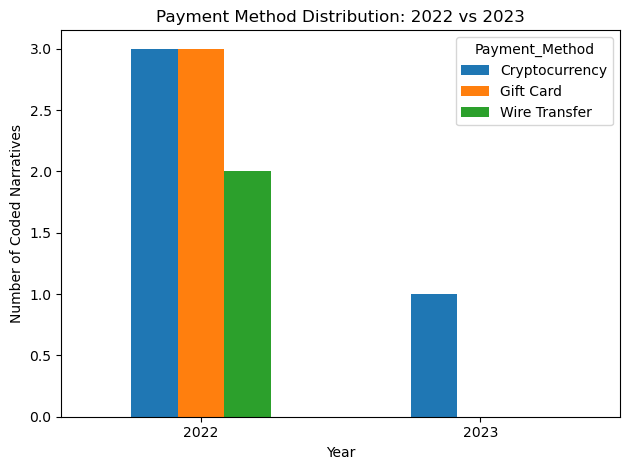

In [73]:
payment_comparison.plot(kind="bar")

plt.title("Payment Method Distribution: 2022 vs 2023")
plt.xlabel("Year")
plt.ylabel("Number of Coded Narratives")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Payment Method Shift: Data Limitation

The current coded scam-narrative dataset contains records for 2020, 2022 and 2023, but no 2024 records. Therefore, a direct 2023–2024 payment-method comparison cannot be calculated from the current dataset without introducing unsupported data. The latest available comparison in this dataset is 2022 versus 2023.

The 2022–2023 comparison is used as an indicative sample-level observation only. It should not be interpreted as a national estimate of scam payment behavior.

## Payment Method Shift Observation

In the coded tactics sample, cryptocurrency transactions decreased from 3 records in 2022 to 1 record in 2023, while gift-card demands decreased from 3 to 0 and wire-transfer demands decreased from 2 to 0. Cryptocurrency therefore remained the only payment method represented in the 2023 records.

This pattern suggests that, within this small coded sample, cryptocurrency remained a viable payment channel while gift-card and wire-transfer demands were not represented in the 2023 records. However, the dataset contains no 2024 tactics records, so a direct 2023–2024 comparison cannot be supported. The observed 2022–2023 change should therefore be treated as a sample-level pattern rather than a national trend.

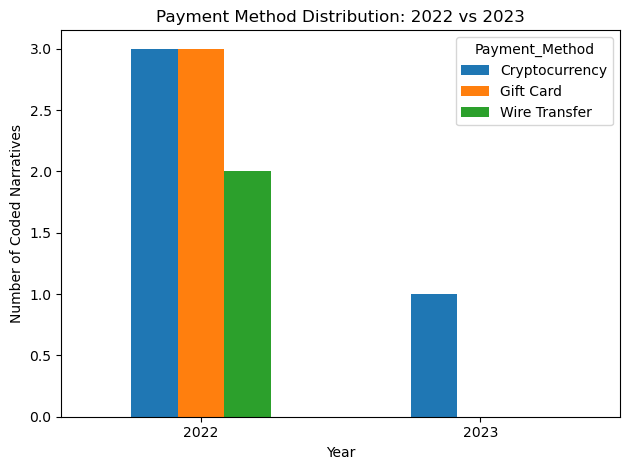

Chart saved: D:\PSYLIQ_Project_1\Visualizations\payment_method_shift_2022_2023.png


In [74]:
payment_comparison.plot(kind="bar")

plt.title("Payment Method Distribution: 2022 vs 2023")
plt.xlabel("Year")
plt.ylabel("Number of Coded Narratives")
plt.xticks(rotation=0)
plt.tight_layout()

chart_path = r"D:\PSYLIQ_Project_1\Visualizations\payment_method_shift_2022_2023.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved:", chart_path)